In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [4]:
list_c_vals=[np.float64(0.9930733865293206), np.float64(0.9917934035299109), np.float64(0.9903239429603026), np.float64(0.9887650048204959), np.float64(0.9871165891104907), np.float64(0.985378695830287), np.float64(0.983451324979885), np.float64(0.9813344765592843), np.float64(0.9791281505684851), np.float64(0.9768323470074877), np.float64(0.9742470658762915), np.float64(0.971672307174897), np.float64(0.9689080709033041), np.float64(0.9660543570615125), np.float64(0.9631111656495226), np.float64(0.9600784966673341), np.float64(0.9572563501149473), np.float64(0.9543447259923619), np.float64(0.950843624299578), np.float64(0.9483530450365956)]
list_c_vals=[np.float64(0.9930733865293206), np.float64(0.9916934035299109), np.float64(0.9903239429603026), np.float64(0.9887650048204959), np.float64(0.9871165891104907), np.float64(0.985178695830287), np.float64(0.983251324979885), np.float64(0.9809344765592843), np.float64(0.9788281505684852), np.float64(0.9762323470074876), np.float64(0.9735470658762915), np.float64(0.971072307174897), np.float64(0.9680080709033041), np.float64(0.9647543570615126), np.float64(0.9614111656495226), np.float64(0.9575784966673342), np.float64(0.9538563501149473), np.float64(0.9496447259923618), np.float64(0.9453436242995781), np.float64(0.9402530450365956)]


## Simulaatio

In [5]:
f_1 = qubit.frequency*1.2 #Ajotaajuudet
f_2 = qubit.frequency*1.4
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7 #Hilbert-avaruuden dimensio

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [6]:
def find_params(f_1_opt,f_2_opt,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range, max_range):
        delta = AC_stark+i/scale
        AC_stark_vals.append(delta)

        f_supp1=(f_ef+delta-2*f_1+f_2)/2+f_1
        f_supp2=f_ef+delta-2*f_1+2*f_2
        
        if A < 3.3:
            sim_vals = pulses.sim_3_part_pulses(f_1_opt,[f_supp1,f_supp2],A,evolution,dim,f_rabi,t_ramp=10,U_f=15,f_2=f_2_opt,K=200, drag=True)
        if A < 3.8:
            sim_vals = pulses.sim_3_part_pulses(f_1_opt,[f_supp1,f_supp2],A,evolution,dim,f_rabi,t_ramp=10,U_f=10,f_2=f_2_opt,K=200, drag=True)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_1_opt,[f_supp1,f_supp2],A,evolution,dim,f_rabi,t_ramp=10,U_f=1,f_2=f_2_opt,K=200, drag=True)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.semilogy(AC_stark_vals, max_f_vals)
    plt.xlabel("delta=ω_supp-ω_ef (GHz)")
    plt.ylabel("Suurin f-tason todennäköisyys")
    plt.show()
    
    index=np.argmin(max_f_vals)
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    delta=AC_stark_vals[index]
    pi_pulse=pulse_times[index]
    
    return(delta,pi_pulse,[e_max,f_max],max_e_vals)

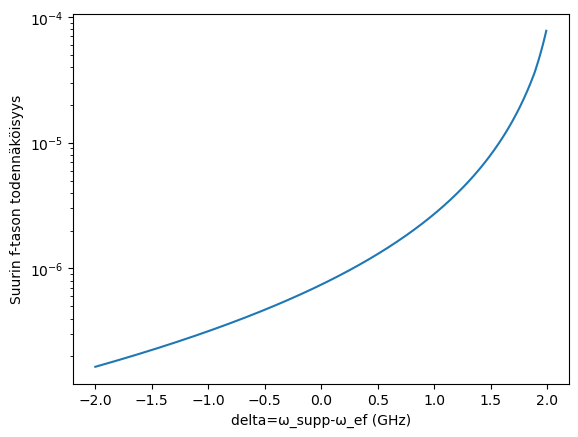

Amplitudi (GHz): 2.0390881111606896
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9969644098738095
F-tason suurin todennäköisyys: 1.725825846995615e-07
Pulssin pituus (ns): 193.76030071338548
Rabi-taajuus (fourier):  0.0027158684142585474


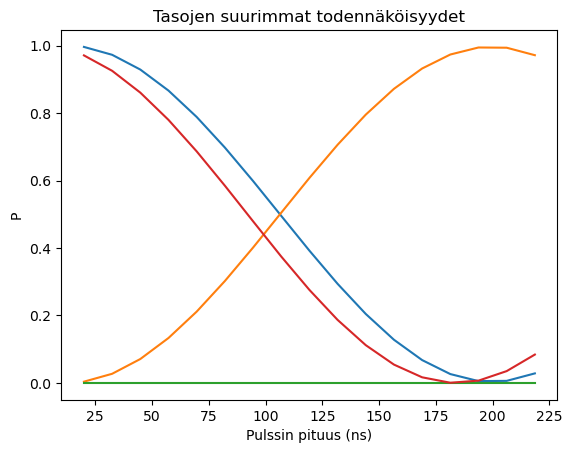

---------------------------------------------


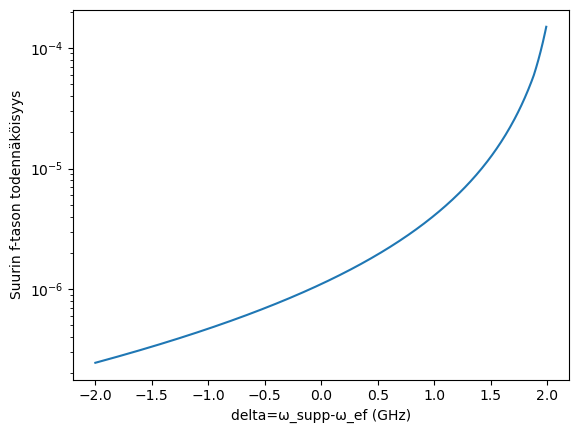

Amplitudi (GHz): 2.21348380487838
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9967285305970823
F-tason suurin todennäköisyys: 2.50239719877597e-07
Pulssin pituus (ns): 156.71593215168346
Rabi-taajuus (fourier):  0.0034982087459609094


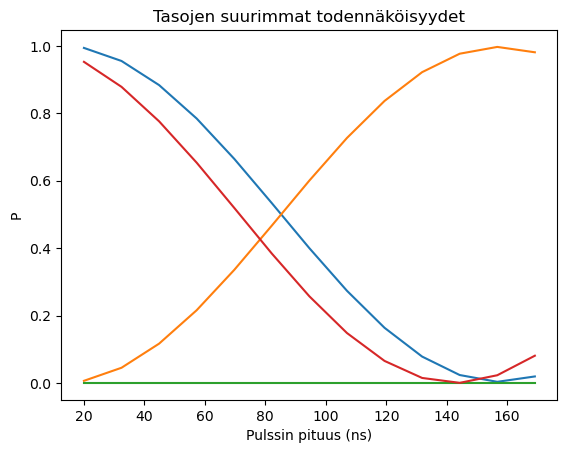

---------------------------------------------


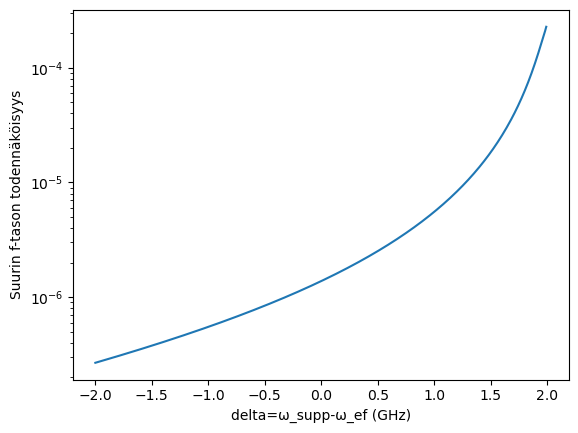

Amplitudi (GHz): 2.3878794985960705
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9999267314698942
F-tason suurin todennäköisyys: 2.722638461488935e-07
Pulssin pituus (ns): 132.01317245041002
Rabi-taajuus (fourier):  0.004402613318981143


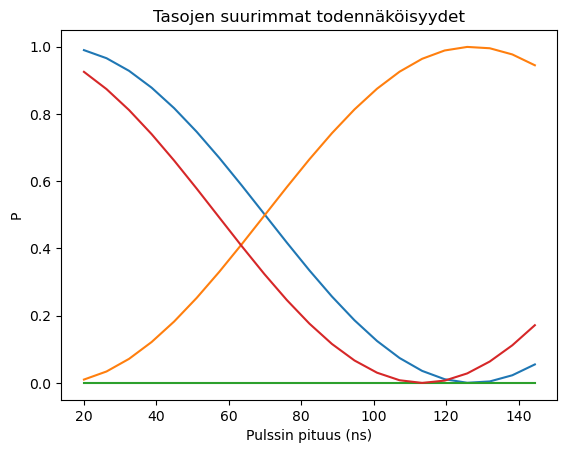

---------------------------------------------


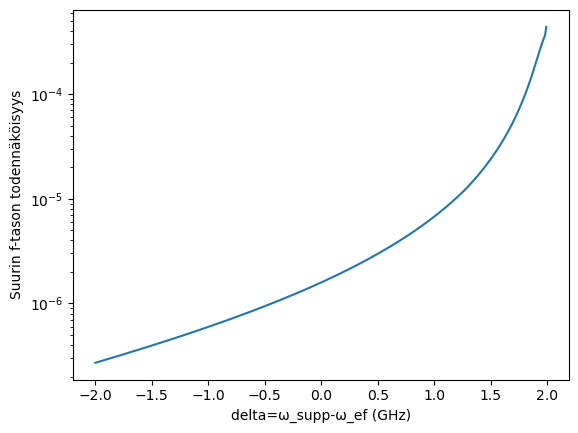

Amplitudi (GHz): 2.562275192313761
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9995963469313283
F-tason suurin todennäköisyys: 2.8889793762188633e-07
Pulssin pituus (ns): 107.25871639496454
Rabi-taajuus (fourier):  0.005469628101247997


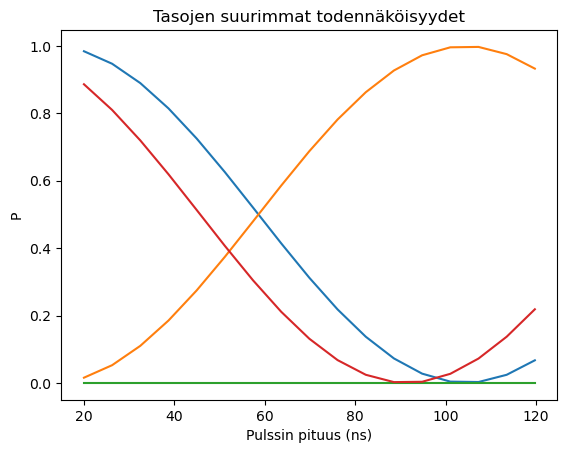

---------------------------------------------


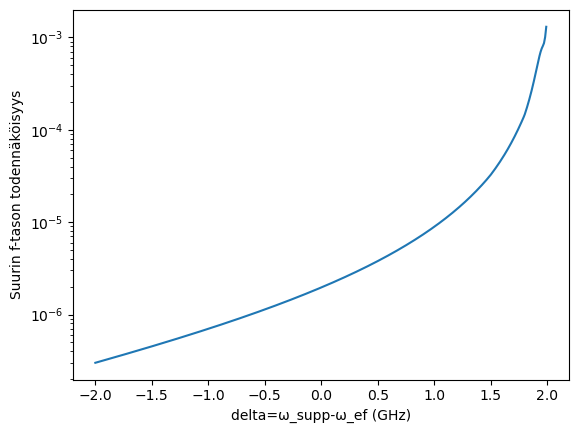

Amplitudi (GHz): 2.7366708860314515
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9995238771055914
F-tason suurin todennäköisyys: 3.4000764096960396e-07
Pulssin pituus (ns): 82.43173739461318
Rabi-taajuus (fourier):  0.006720626993421177


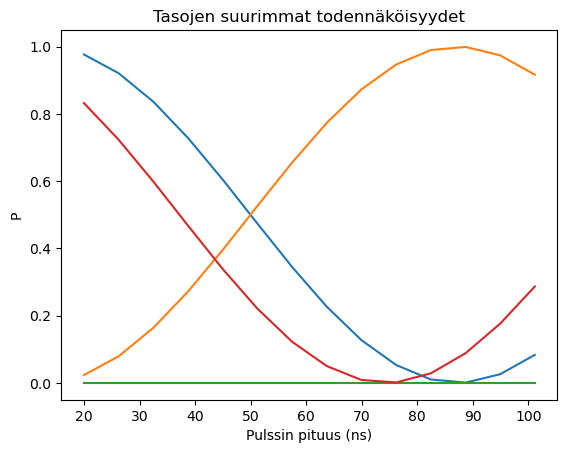

---------------------------------------------


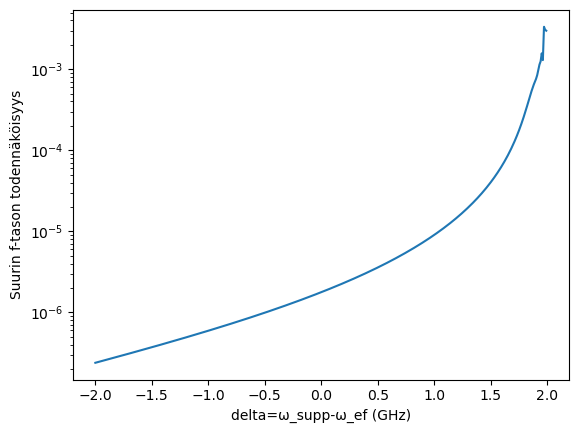

Amplitudi (GHz): 2.9110665797491424
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.996317201304563
F-tason suurin todennäköisyys: 3.4756491493903815e-07
Pulssin pituus (ns): 70.0436348695293
Rabi-taajuus (fourier):  0.008128499500035928


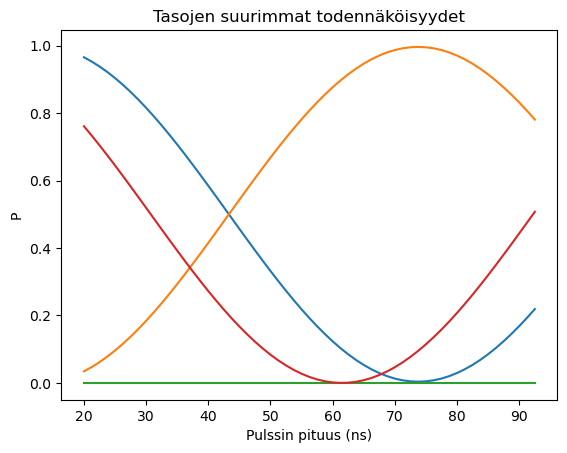

---------------------------------------------


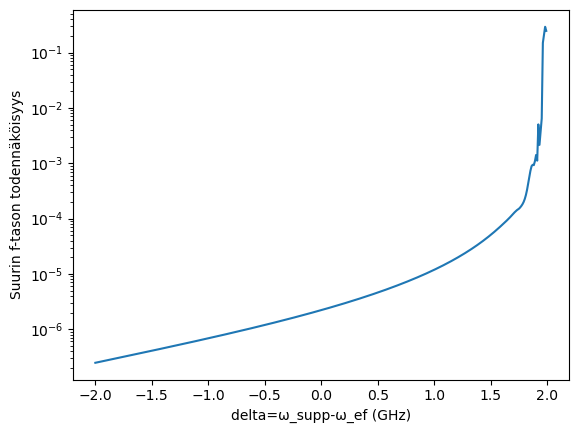

Amplitudi (GHz): 3.0854622734668324
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9981758142208551
F-tason suurin todennäköisyys: 3.219110961758288e-07
Pulssin pituus (ns): 57.60629786314695
Rabi-taajuus (fourier):  0.009828403146937798


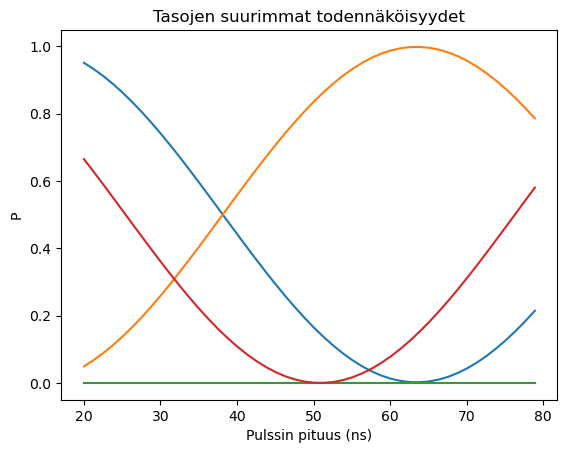

---------------------------------------------


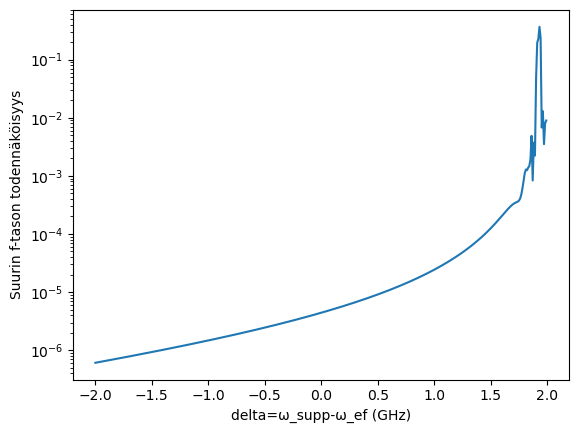

Amplitudi (GHz): 3.2598579671845234
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9901074050347793
F-tason suurin todennäköisyys: 6.083229724752632e-07
Pulssin pituus (ns): 57.695119383738714
Rabi-taajuus (fourier):  0.011790503696777605


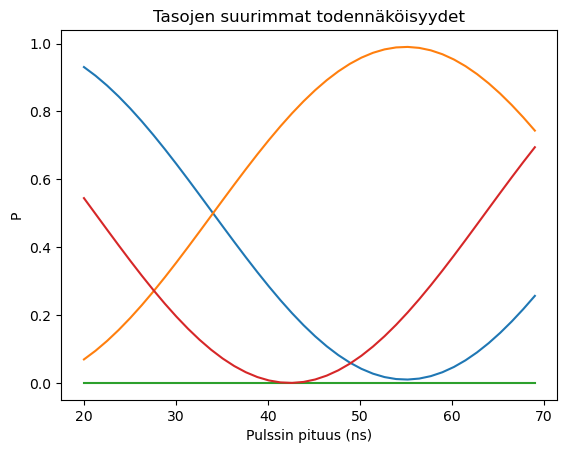

---------------------------------------------


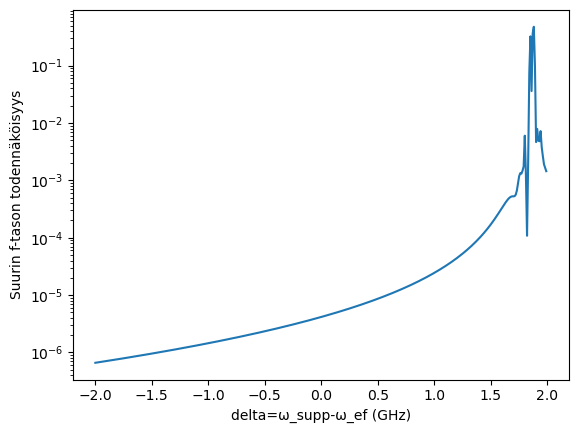

Amplitudi (GHz): 3.4342536609022134
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9974903346168533
F-tason suurin todennäköisyys: 9.064281224132989e-07
Pulssin pituus (ns): 45.18415664012949
Rabi-taajuus (fourier):  0.014055753620945383


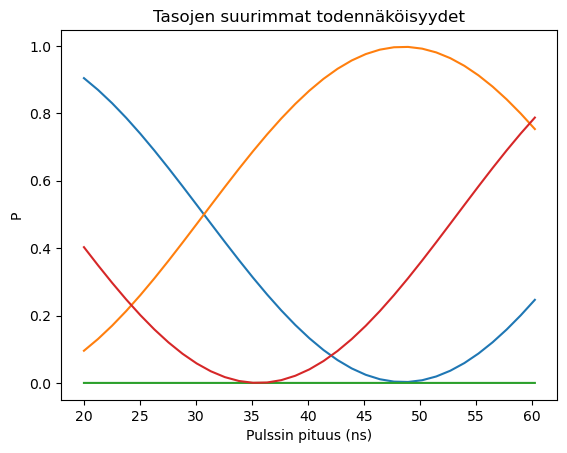

---------------------------------------------


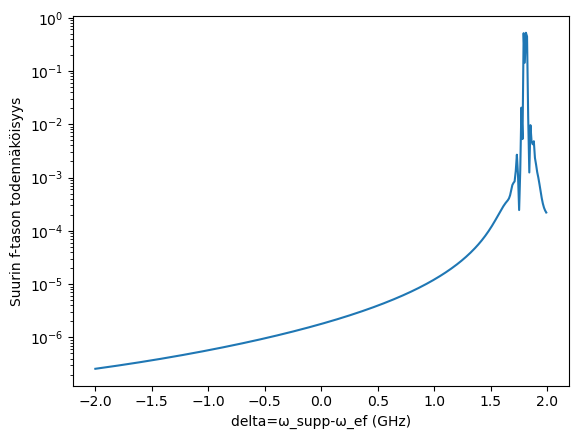

Amplitudi (GHz): 3.6086493546199043
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9926913026719807
F-tason suurin todennäköisyys: 1.0793913887120746e-06
Pulssin pituus (ns): 32.62556067889436
Rabi-taajuus (fourier):  0.016616308386280844


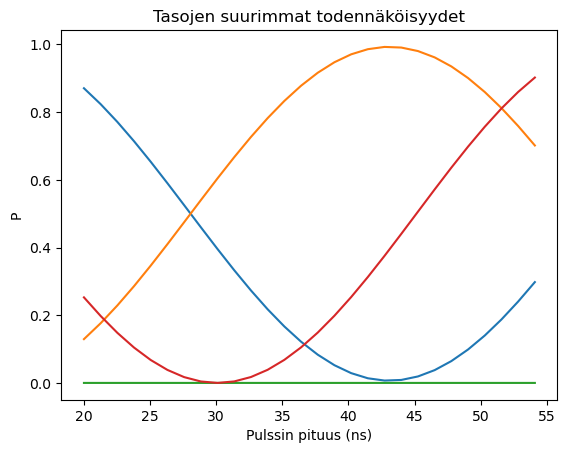

---------------------------------------------


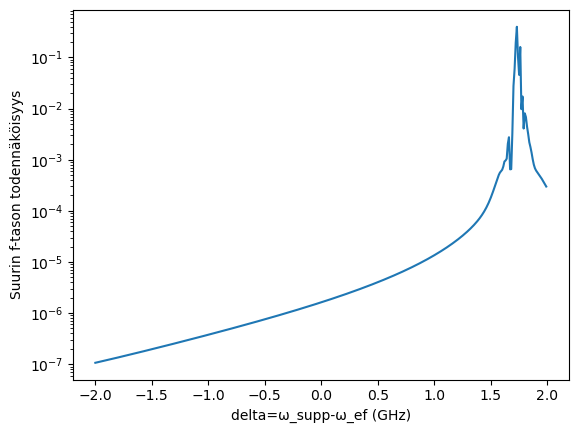

Amplitudi (GHz): 3.783045048337595
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9917090289220474
F-tason suurin todennäköisyys: 6.207033252916155e-07
Pulssin pituus (ns): 32.660385065973465
Rabi-taajuus (fourier):  0.019583439445604


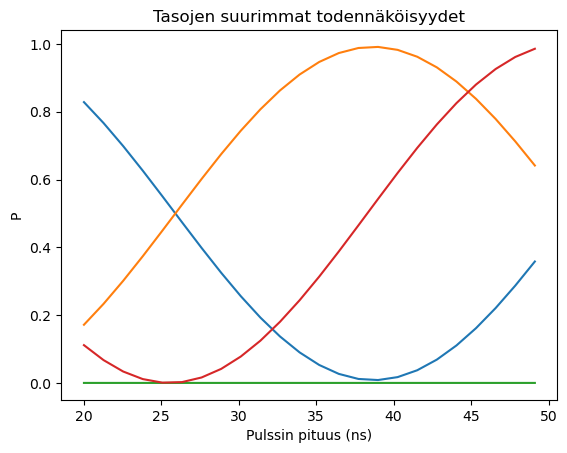

---------------------------------------------


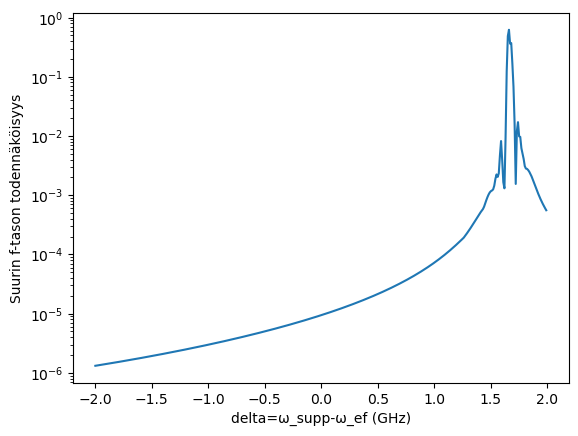

Amplitudi (GHz): 3.9574407420552853
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9976561474389087
F-tason suurin todennäköisyys: 1.3142602468984219e-06
Pulssin pituus (ns): 35.231179770372236
Rabi-taajuus (fourier):  0.022947307324589102


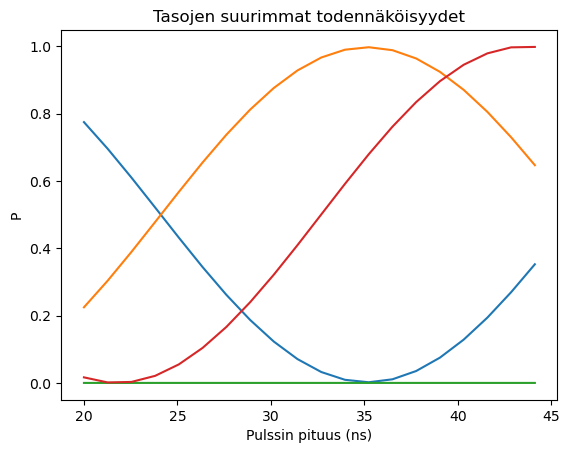

---------------------------------------------


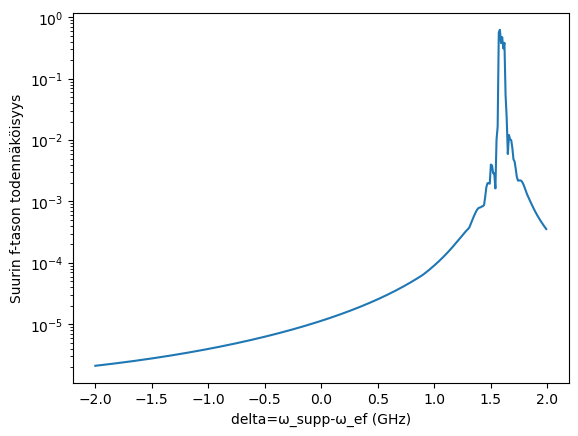

Amplitudi (GHz): 4.131836435772976
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9937274851722361
F-tason suurin todennäköisyys: 2.1083867208832336e-06
Pulssin pituus (ns): 32.732828479767605
Rabi-taajuus (fourier):  0.026622761108115157


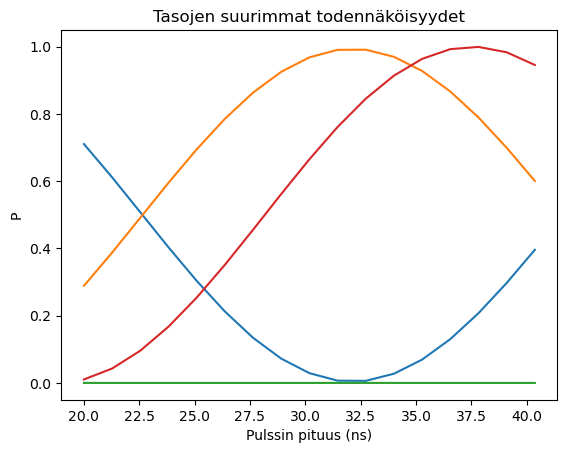

---------------------------------------------


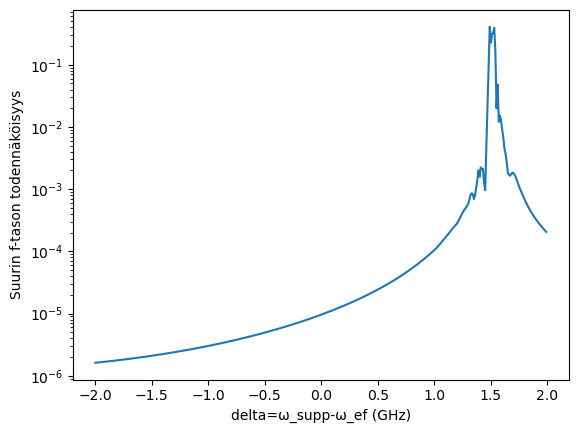

Amplitudi (GHz): 4.306232129490666
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.990163494497394
F-tason suurin todennäköisyys: 1.6192681384131117e-06
Pulssin pituus (ns): 30.22061679732356
Rabi-taajuus (fourier):  0.030897301008966982


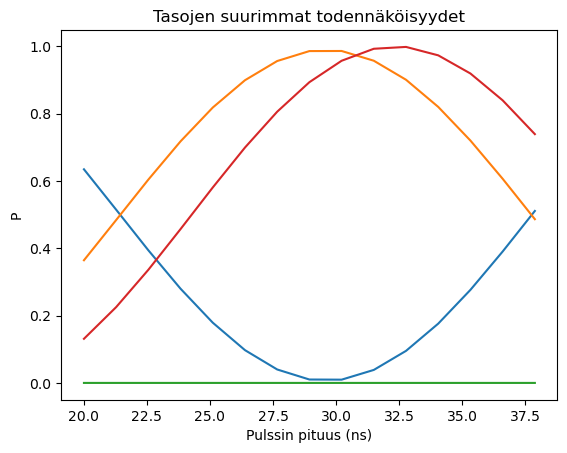

---------------------------------------------


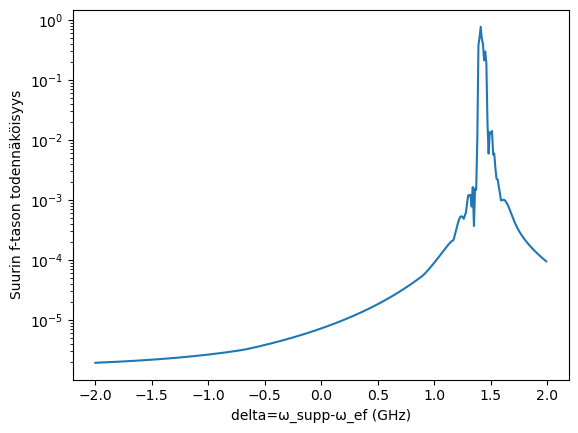

Amplitudi (GHz): 4.480627823208358
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9875626621922053
F-tason suurin todennäköisyys: 1.935497063958225e-06
Pulssin pituus (ns): 27.692118319958652
Rabi-taajuus (fourier):  0.03572607035857721


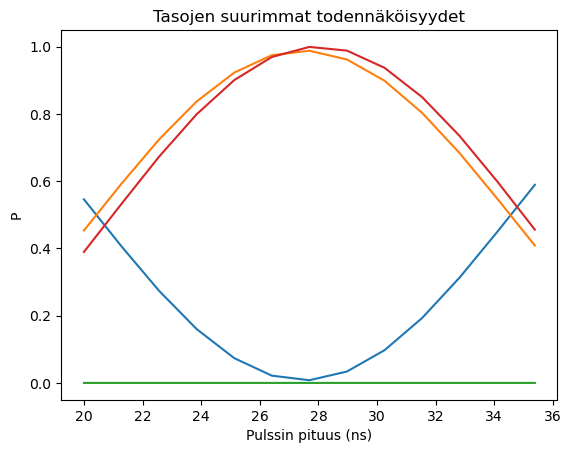

---------------------------------------------


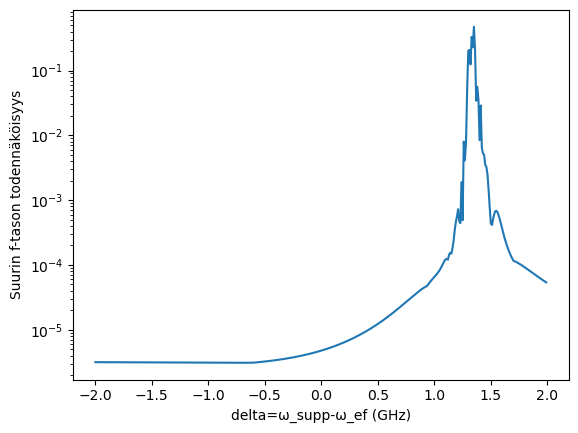

Amplitudi (GHz): 4.655023516926048
AC-stark siirtymä (GHz): -0.74
E-tason suurin todennäköisyys: 0.9876172139033619
F-tason suurin todennäköisyys: 3.0970957055554066e-06
Pulssin pituus (ns): 25.148603807098397
Rabi-taajuus (fourier):  0.04088998176539052


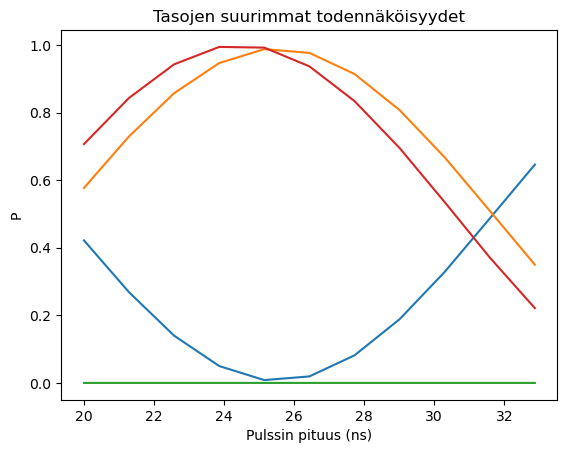

---------------------------------------------


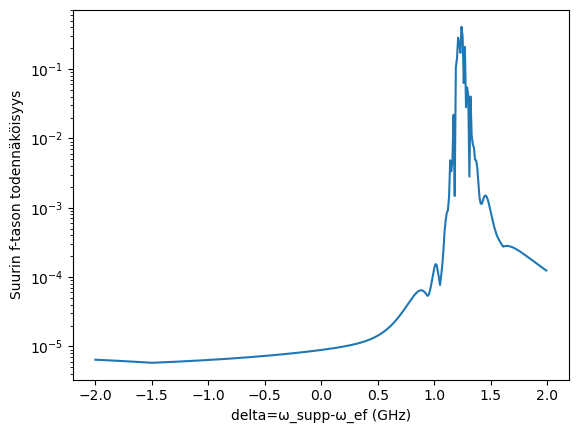

Amplitudi (GHz): 4.829419210643738
AC-stark siirtymä (GHz): -1.5
E-tason suurin todennäköisyys: 0.9808733052851348
F-tason suurin todennäköisyys: 7.055088654223259e-06
Pulssin pituus (ns): 23.876521050268366
Rabi-taajuus (fourier):  0.04643338644776322


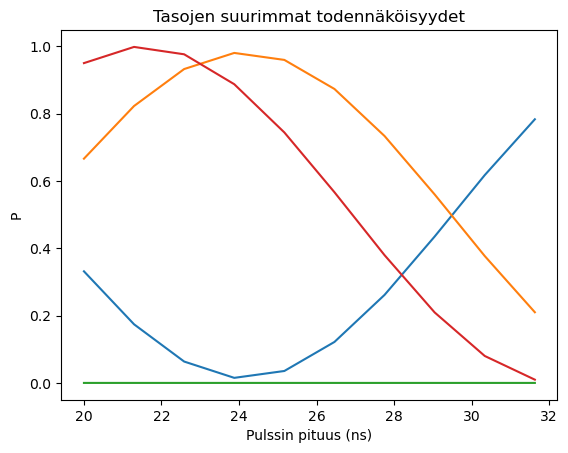

---------------------------------------------


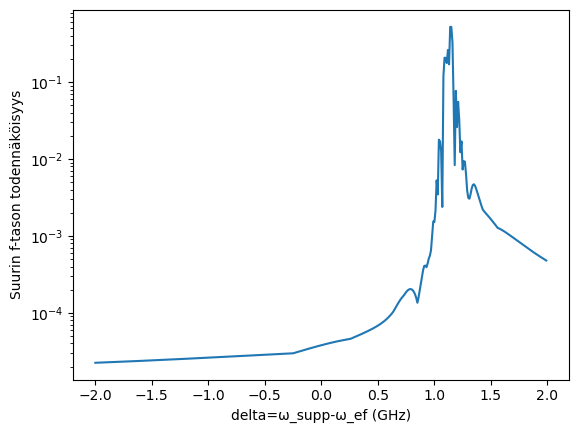

Amplitudi (GHz): 5.003814904361429
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9696130540434515
F-tason suurin todennäköisyys: 3.184234493012607e-05
Pulssin pituus (ns): 22.595808810702884
Rabi-taajuus (fourier):  0.053136052976648196


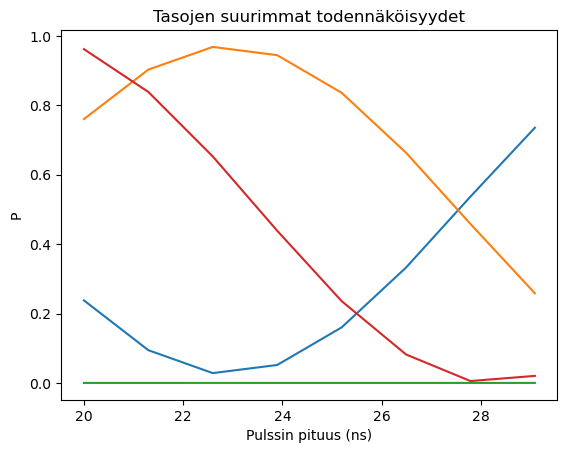

---------------------------------------------


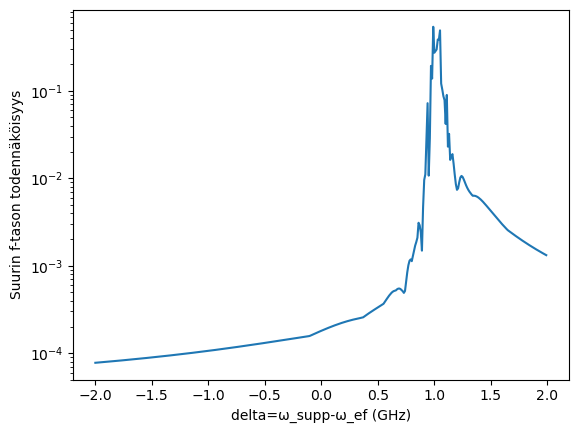

Amplitudi (GHz): 5.178210598079119
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9548745338615843
F-tason suurin todennäköisyys: 0.00012786125899882797
Pulssin pituus (ns): 21.303809579609176
Rabi-taajuus (fourier):  0.059764922072006475


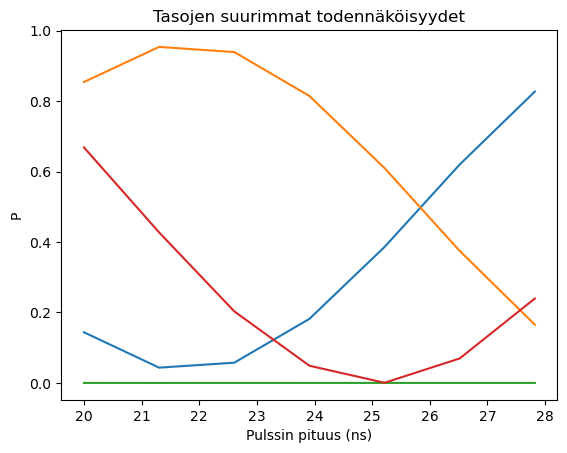

---------------------------------------------


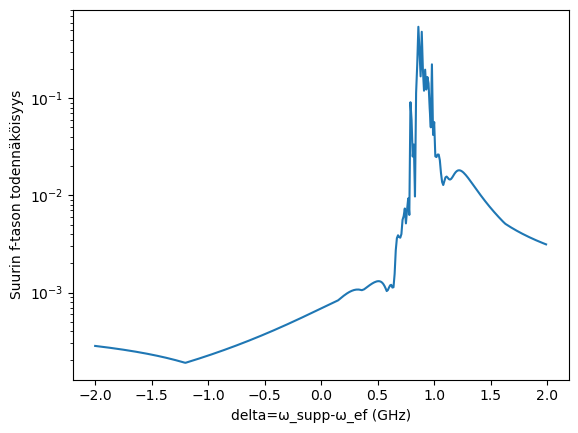

Amplitudi (GHz): 5.35260629179681
AC-stark siirtymä (GHz): -1.2
E-tason suurin todennäköisyys: 0.9575622670048506
F-tason suurin todennäköisyys: 0.00039091170221665117
Pulssin pituus (ns): 21.31086847300375
Rabi-taajuus (fourier):  0.06731056237508168


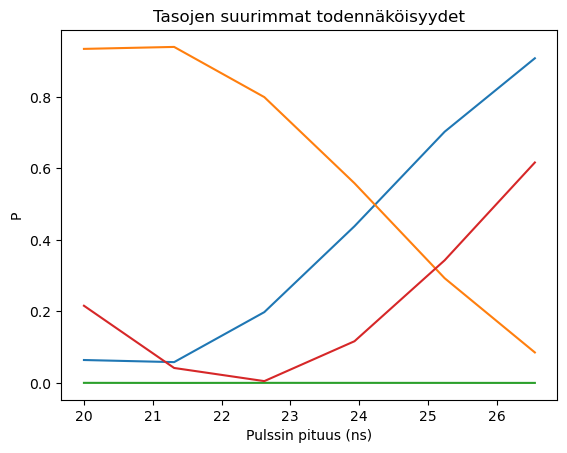

---------------------------------------------


In [7]:
c_vals = [] #c:n arvot
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals= []

min_range = 0.08
max_range = 0.21
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)
    
    f_1_opt=f_1*list_c_vals[i]
    f_2_opt=f_2*list_c_vals[i]

    f_rabi= 0.0009703*A**3 - 0.00434*A**2 + 0.009973*A - 0.007682 #Arvaus Rabi-taajuudelle
    AC_stark=0

    params=find_params(f_1_opt,f_2_opt, A, evolution_eigenbasis,10*f_rabi,AC_stark,[-200,200],100)
    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    f_supp1=(f_ef+deltas[-1]-2*f_1+f_2)/2+f_1
    f_supp2=f_ef+deltas[-1]-2*f_1+2*f_2
    
    m=10

    if A < 2.3:
        vals = pulses.sim_3_part_pulses(f_1_opt,[f_supp1,f_supp2],A,evolution_eigenbasis,dim,(f_rabi*10)/m,t_ramp=10,U_f=10,f_2=f_2_opt,K=200, drag=True)
    elif A < 2.9:
        vals = pulses.sim_3_part_pulses(f_1_opt,[f_supp1,f_supp2],A,evolution_eigenbasis,dim,(f_rabi*10)/m,t_ramp=10,U_f=5,f_2=f_2_opt,K=200, drag=True)
    else:
        vals = pulses.sim_3_part_pulses(f_1_opt,[f_supp1,f_supp2],A,evolution_eigenbasis,dim,(f_rabi*10)/m,t_ramp=10,U_f=1,f_2=f_2_opt,K=200, drag=True)
    
    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("F-tason suurin todennäköisyys:", vals[1])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    max_vals.append([vals[0],vals[1]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 
    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(2.0390881111606896), np.float64(2.21348380487838), np.float64(2.3878794985960705), np.float64(2.562275192313761), np.float64(2.7366708860314515), np.float64(2.9110665797491424), np.float64(3.0854622734668324), np.float64(3.2598579671845234), np.float64(3.4342536609022134), np.float64(3.6086493546199043), np.float64(3.783045048337595), np.float64(3.9574407420552853), np.float64(4.131836435772976), np.float64(4.306232129490666), np.float64(4.480627823208358), np.float64(4.655023516926048), np.float64(4.829419210643738), np.float64(5.003814904361429), np.float64(5.178210598079119), np.float64(5.35260629179681)]


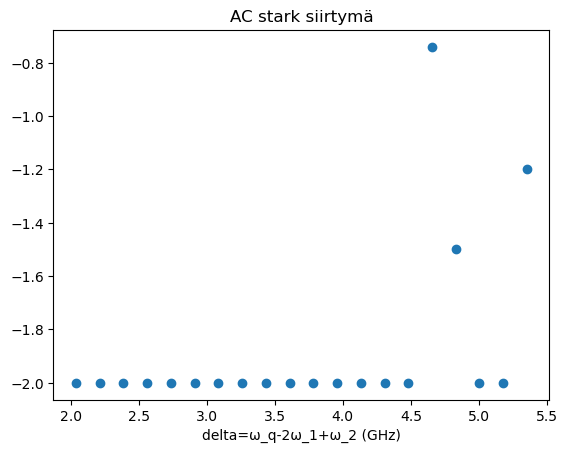

[-2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -0.74, -1.5, -2.0, -2.0, -1.2]
[]


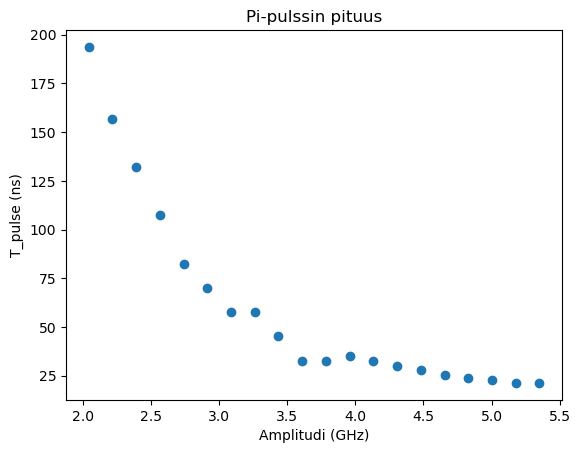

[np.float64(193.76030071338548), np.float64(156.71593215168346), np.float64(132.01317245041002), np.float64(107.25871639496454), np.float64(82.43173739461318), np.float64(70.0436348695293), np.float64(57.60629786314695), np.float64(57.695119383738714), np.float64(45.18415664012949), np.float64(32.62556067889436), np.float64(32.660385065973465), np.float64(35.231179770372236), np.float64(32.732828479767605), np.float64(30.22061679732356), np.float64(27.692118319958652), np.float64(25.148603807098397), np.float64(23.876521050268366), np.float64(22.595808810702884), np.float64(21.303809579609176), np.float64(21.31086847300375)]


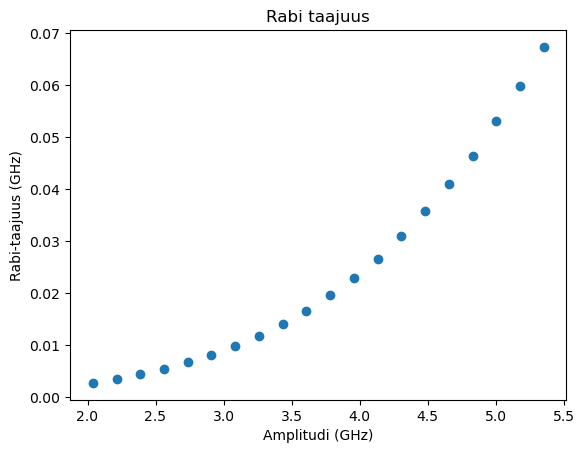

[np.float64(0.0027158684142585474), np.float64(0.0034982087459609094), np.float64(0.004402613318981143), np.float64(0.005469628101247997), np.float64(0.006720626993421177), np.float64(0.008128499500035928), np.float64(0.009828403146937798), np.float64(0.011790503696777605), np.float64(0.014055753620945383), np.float64(0.016616308386280844), np.float64(0.019583439445604), np.float64(0.022947307324589102), np.float64(0.026622761108115157), np.float64(0.030897301008966982), np.float64(0.03572607035857721), np.float64(0.04088998176539052), np.float64(0.04643338644776322), np.float64(0.053136052976648196), np.float64(0.059764922072006475), np.float64(0.06731056237508168)]


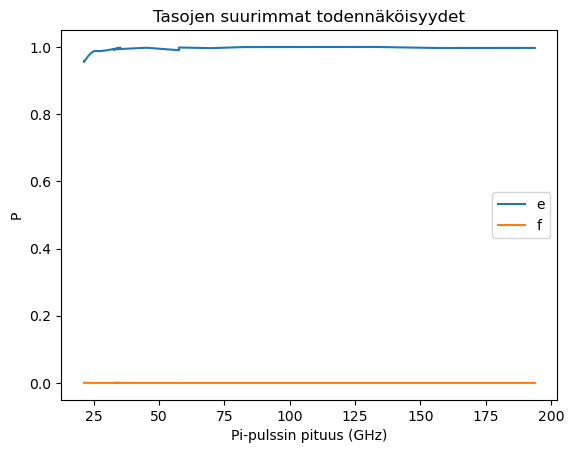

[np.float64(0.9969644098738095), np.float64(0.9967285305970823), np.float64(0.9999267314698942), np.float64(0.9995963469313283), np.float64(0.9995238771055914), np.float64(0.996317201304563), np.float64(0.9981758142208551), np.float64(0.9901074050347793), np.float64(0.9974903346168533), np.float64(0.9926913026719807), np.float64(0.9917090289220474), np.float64(0.9976561474389087), np.float64(0.9937274851722361), np.float64(0.990163494497394), np.float64(0.9875626621922053), np.float64(0.9876172139033619), np.float64(0.9808733052851348), np.float64(0.9696130540434515), np.float64(0.9548745338615843), np.float64(0.9575622670048506)]
[np.float64(1.725825846995615e-07), np.float64(2.50239719877597e-07), np.float64(2.722638461488935e-07), np.float64(2.8889793762188633e-07), np.float64(3.4000764096960396e-07), np.float64(3.4756491493903815e-07), np.float64(3.219110961758288e-07), np.float64(6.083229724752632e-07), np.float64(9.064281224132989e-07), np.float64(1.0793913887120746e-06), np.floa

'\nplt.figure(figsize=(6, 6))\nplt.imshow(data, aspect=\'auto\')  # stretches to square\nplt.colorbar(label="e-tason suurin todennäköisyys")\nplt.show() '

In [ ]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=ω_q-2ω_1+ω_2 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)
print(c_vals)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

"""
plt.figure(figsize=(6, 6))
plt.imshow(data, aspect='auto')  # stretches to square
plt.colorbar(label="e-tason suurin todennäköisyys")
plt.show() """